In [10]:
!rm -rf /content/sequence-modelling

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [1]:
!git clone https://github.com/Dorcas-Joy-Kahunguka/sequence-modelling/

Cloning into 'sequence-modelling'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 159 (delta 52), reused 141 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 141.71 KiB | 1.17 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [7]:
%cd /content/sequence-modelling/mechinterp-typoglycemia
%ls /content/sequence-modelling/mechinterp-typoglycemia

/content/sequence-modelling/mechinterp-typoglycemia
data/  environment.yml  notebooks/  pyproject.toml  src/  tests/


In [8]:
from google.colab import drive
drive.mount("/content/drive")

import os
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/sequence-modelling/mechinterp-typoglycemia


In [27]:
from pathlib import Path


RECORDS_CSV = Path("/content/drive/MyDrive/typoglycemia_activations/behavioural_evaluation_results.csv")          
RECORDS_JSON = Path("/content/drive/MyDrive/typoglycemia_activations/behavioural_evaluation_results.json")        
BOS_TOKEN_JSON = Path("/content/drive/MyDrive/typoglycemia_activations/bos_token.json")

# Where to save the annotated records back out to (can be the same paths
# as above to overwrite, or new paths to keep the originals untouched).
ANNOTATED_CSV_OUT = Path("/content/drive/MyDrive/typoglycemia_activations/tokenization_analysis_results.csv")
ANNOTATED_JSON_OUT = Path("/content/drive/MyDrive/typoglycemia_activations/tokenization_analysis_results.json")
# --------------------------------------------------------------------------- #


In [28]:
import pandas as pd
import torch

from src import probe_utils as pu

pd.set_option("display.max_colwidth", 120)


In [32]:
bos_meta = pu.load_bos_token(BOS_TOKEN_JSON)
print("bos_token metadata:", bos_meta)

df = pu.load_records(csv_path=RECORDS_CSV, json_path=RECORDS_JSON)
print(f"Loaded {len(df)} records")
df.head()


bos_token metadata: {'bose_token_id': 50256, 'bos_token': '<|endoftext|>'}


Loaded 5 records


,id,clean_sentence,scrambled_sentence,target_word,clean_top1,clean_top_k,scrambled_top1,scrambled_top_k,cache_path,pred_cosine_sim,pred_wordnet_wup,pred_wordnet_path,consistency_category,tokenization_is_same,tokenization_message
0,0,I'm building my first ever company this,I'm bdiinlug my frist eevr cnpaomy tihs,year,year,"['year', 'week', 'summer', 'month', 'fall']",.,"['.', 't', ',', 'e', 'n']",/content/drive/MyDrive/typoglycemia_activations/0.pt,0.221542,NaN,NaN,unrelated,False,"clean tokenized to ['<|endoftext|>', 'I', ""'m"", ' building', ' my', ' first', ' ever', ' company', ' this'] and scra..."
1,1,Maria can drink Java dawa even on a hot,Miraa can dnirk Jvaa dwaa eevn on a hot,day,day,"['day', 'summer', 'afternoon', 'morning', 'night']",day,"['day', '-', 'bed', 'spot', 'd']",/content/drive/MyDrive/typoglycemia_activations/1.pt,1.000000,1.000000,1.000000,identical,False,"clean tokenized to ['<|endoftext|>', 'Maria', ' can', ' drink', ' Java', ' d', 'awa', ' even', ' on', ' a', ' hot'] ..."
2,2,Who tried to bribe the policemen and the,Who treid to bibre the piocelmen and the,judge,police,"['police', 'cops', 'policemen', 'soldiers', 'army']",p,"['p', 'b', 'c', 'g', 'm']",/content/drive/MyDrive/typoglycemia_activations/2.pt,0.264868,0.285714,0.090909,unrelated,False,"clean tokenized to ['<|endoftext|>', 'Who', ' tried', ' to', ' bribe', ' the', ' policemen', ' and', ' the'] and scr..."
3,3,Dr. Wang won the,Dr. Wnag won the,grant,Nobel,"['Nobel', 'prestigious', '2015', '2014', '2016']",Nobel,"['Nobel', 'award', '2016', '2015', 'prestigious']",/content/drive/MyDrive/typoglycemia_activations/3.pt,1.000000,0.916667,1.000000,identical,False,"clean tokenized to ['<|endoftext|>', 'Dr', '.', ' Wang', ' won', ' the'] and scramble tokenized to ['<|endoftext|>',..."
4,4,A well-known baker came up with the,A wowkl-nlen beakr cmae up wtih the,idea,idea,"['idea', 'name', 'concept', 'recipe', 'perfect']",n,"['n', 'c', 'g', 'w', 'l']",/content/drive/MyDrive/typoglycemia_activations/4.pt,0.204118,0.307692,0.100000,unrelated,False,"clean tokenized to ['<|endoftext|>', 'A', ' well', '-', 'known', ' baker', ' came', ' up', ' with', ' the'] and scra..."


In [33]:
example_row = df.iloc[0]
example_comparison = pu.compare_tokenization_from_cache(example_row["cache_path"])

print("id:", example_row["id"])
print("is_same:", example_comparison.is_same)
print("message:", example_comparison.message)


id: 0
is_same: False
message: clean tokenized to ['<|endoftext|>', 'I', "'m", ' building', ' my', ' first', ' ever', ' company', ' this'] and scramble tokenized to ['<|endoftext|>', 'I', "'m", ' b', 'di', 'in', 'l', 'ug', ' my', ' fr', 'ist', ' e', 'ev', 'r', ' c', 'n', 'pa', 'omy', ' t', 'ih', 's']


In [34]:
df_annotated = pu.annotate_tokenization(df, cache_path_col="cache_path", verbose=False)
df_annotated[["id", "clean_sentence", "scrambled_sentence",
              "consistency_category", "tokenization_is_same", "tokenization_message"]].head(10)


,id,clean_sentence,scrambled_sentence,consistency_category,tokenization_is_same,tokenization_message
0,0,I'm building my first ever company this,I'm bdiinlug my frist eevr cnpaomy tihs,unrelated,False,"clean tokenized to ['<|endoftext|>', 'I', ""'m"", ' building', ' my', ' first', ' ever', ' company', ' this'] and scra..."
1,1,Maria can drink Java dawa even on a hot,Miraa can dnirk Jvaa dwaa eevn on a hot,identical,False,"clean tokenized to ['<|endoftext|>', 'Maria', ' can', ' drink', ' Java', ' d', 'awa', ' even', ' on', ' a', ' hot'] ..."
2,2,Who tried to bribe the policemen and the,Who treid to bibre the piocelmen and the,unrelated,False,"clean tokenized to ['<|endoftext|>', 'Who', ' tried', ' to', ' bribe', ' the', ' policemen', ' and', ' the'] and scr..."
3,3,Dr. Wang won the,Dr. Wnag won the,identical,False,"clean tokenized to ['<|endoftext|>', 'Dr', '.', ' Wang', ' won', ' the'] and scramble tokenized to ['<|endoftext|>',..."
4,4,A well-known baker came up with the,A wowkl-nlen beakr cmae up wtih the,unrelated,False,"clean tokenized to ['<|endoftext|>', 'A', ' well', '-', 'known', ' baker', ' came', ' up', ' with', ' the'] and scra..."


In [35]:
for _, row in df_annotated.iterrows():
    print(f"[id={row['id']}] {row['tokenization_message']}")


[id=0] clean tokenized to ['<|endoftext|>', 'I', "'m", ' building', ' my', ' first', ' ever', ' company', ' this'] and scramble tokenized to ['<|endoftext|>', 'I', "'m", ' b', 'di', 'in', 'l', 'ug', ' my', ' fr', 'ist', ' e', 'ev', 'r', ' c', 'n', 'pa', 'omy', ' t', 'ih', 's']
[id=1] clean tokenized to ['<|endoftext|>', 'Maria', ' can', ' drink', ' Java', ' d', 'awa', ' even', ' on', ' a', ' hot'] and scramble tokenized to ['<|endoftext|>', 'Mir', 'aa', ' can', ' d', 'n', 'irk', ' J', 'va', 'a', ' dw', 'aa', ' e', 'ev', 'n', ' on', ' a', ' hot']
[id=2] clean tokenized to ['<|endoftext|>', 'Who', ' tried', ' to', ' bribe', ' the', ' policemen', ' and', ' the'] and scramble tokenized to ['<|endoftext|>', 'Who', ' tre', 'id', ' to', ' b', 'ib', 're', ' the', ' p', 'io', 'cel', 'men', ' and', ' the']
[id=3] clean tokenized to ['<|endoftext|>', 'Dr', '.', ' Wang', ' won', ' the'] and scramble tokenized to ['<|endoftext|>', 'Dr', '.', ' W', 'n', 'ag', ' won', ' the']
[id=4] clean tokenized t

In [36]:
pu.save_records(df_annotated, csv_path=ANNOTATED_CSV_OUT, json_path=ANNOTATED_JSON_OUT)
print(f"Saved annotated records to:\n  {ANNOTATED_CSV_OUT}\n  {ANNOTATED_JSON_OUT}")


Saved annotated records to:
  /content/drive/MyDrive/typoglycemia_activations/tokenization_analysis_results.csv
  /content/drive/MyDrive/typoglycemia_activations/tokenization_analysis_results.json


In [37]:
for category, group in df_annotated.groupby("consistency_category"):
    same = group[group["tokenization_is_same"] == True]
    diff = group[group["tokenization_is_same"] == False]
    missing = group[group["tokenization_is_same"].isna()]

    print(f"=== consistency_category = {category!r} (n={len(group)}) ===")
    print(f"  tokenization_is_same:      {len(same)}")
    print(f"  tokenization_is_different: {len(diff)}")
    if len(missing):
        print(f"  (cache load failures:      {len(missing)})")
    print()


=== consistency_category = 'identical' (n=2) ===
  tokenization_is_same:      0
  tokenization_is_different: 2

=== consistency_category = 'unrelated' (n=3) ===
  tokenization_is_same:      0
  tokenization_is_different: 3



In [38]:
identical_same = df_annotated[
    (df_annotated["consistency_category"] == "identical") &
    (df_annotated["tokenization_is_same"] == True)
]
identical_diff = df_annotated[
    (df_annotated["consistency_category"] == "identical") &
    (df_annotated["tokenization_is_same"] == False)
]

print(f"identical + same tokenization: {len(identical_same)} rows")
print(f"identical + different tokenization: {len(identical_diff)} rows")
identical_diff[["id", "clean_sentence", "scrambled_sentence", "tokenization_message"]].head()


identical + same tokenization: 0 rows
identical + different tokenization: 2 rows


,id,clean_sentence,scrambled_sentence,tokenization_message
1,1,Maria can drink Java dawa even on a hot,Miraa can dnirk Jvaa dwaa eevn on a hot,"clean tokenized to ['<|endoftext|>', 'Maria', ' can', ' drink', ' Java', ' d', 'awa', ' even', ' on', ' a', ' hot'] ..."
3,3,Dr. Wang won the,Dr. Wnag won the,"clean tokenized to ['<|endoftext|>', 'Dr', '.', ' Wang', ' won', ' the'] and scramble tokenized to ['<|endoftext|>',..."


In [42]:
related_same = df_annotated[
    (df_annotated["consistency_category"] == "related") &
    (df_annotated["tokenization_is_same"] == True)
]
related_diff = df_annotated[
    (df_annotated["consistency_category"] == "related") &
    (df_annotated["tokenization_is_same"] == False)
]

print(f"related + same tokenization: {len(related_same)} rows")
print(f"related + different tokenization: {len(related_diff)} rows")
related_diff[["id", "clean_sentence", "scrambled_sentence", "tokenization_message"]].head()

related + same tokenization: 0 rows
related + different tokenization: 0 rows


,id,clean_sentence,scrambled_sentence,tokenization_message


In [ ]:
unrelated_same = df_annotated[
    (df_annotated["consistency_category"] == "unrelated") &
    (df_annotated["tokenization_is_same"] == True)
]
unrelated_diff = df_annotated[
    (df_annotated["consistency_category"] == "unrelated") &
    (df_annotated["tokenization_is_same"] == False)
]

print(f"unrelated + same tokenization: {len(unrelated_same)} rows")
print(f"unrelated + different tokenization: {len(unrelated_diff)} rows")
unrelated_diff[["id", "clean_sentence", "scrambled_sentence", "tokenization_message"]].head()

In [39]:
confusion = pu.tokenization_confusion_matrix(df_annotated)
confusion


consistency_category,identical,unrelated,total
_tok_label,,,
tokenization_is_same,0,0,0
tokenization_is_different,2,3,5
total,2,3,5


In [40]:
props = confusion.drop(columns="total").drop(index="total").astype(float)
props = props.div(props.sum(axis=1), axis=0)
props


consistency_category,identical,unrelated
_tok_label,,
tokenization_is_same,NaN,NaN
tokenization_is_different,0.4,0.6


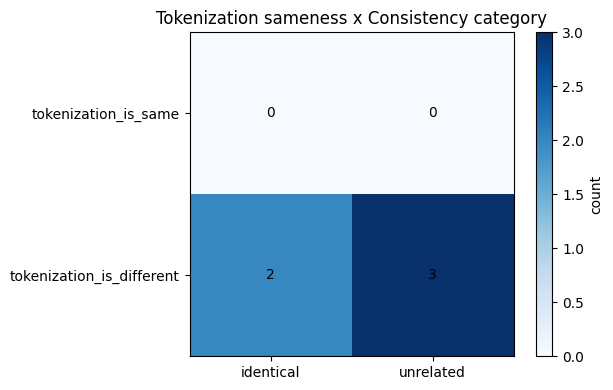

In [41]:
import matplotlib.pyplot as plt

plot_data = confusion.drop(columns="total").drop(index="total")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(plot_data.values, cmap="Blues")

ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels(plot_data.columns)
ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        ax.text(j, i, int(plot_data.values[i, j]), ha="center", va="center")

ax.set_title("Tokenization sameness x Consistency category")
fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()
